# Binary Diabetes Prediction (Normal vs Diabetes/Pre-diabetes)
**Random Forest Classifier with Hyperparameter Tuning**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from scipy.stats import randint, uniform

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & Exploration

In [2]:
df = pd.read_csv('diana_dataset_binary.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1376, 22)


,SEQN,age,hba1c,fbs,bmi,total_cholesterol,ldl,hdl,triglycerides,systolic,diastolic,waist_circumference,family_history_diabetes,race_ethnicity,smoking_status,physical_activity,alcohol_use,cycle,diabetes_status,diabetes_label,menopausal_status,has_outlier
0,130396.0,56.0,5.0,104.0,27.3,214.0,124.0,68.0,108.5,122.0,79.0,97.9,0,3,1,1,0,2021-2023,Normal,0,Postmenopausal,False
1,130416.0,59.0,5.3,91.0,32.9,189.0,126.0,47.0,90.8,135.0,85.0,88.3,0,2,0,1,0,2021-2023,Normal,0,Postmenopausal,False
2,130599.0,54.0,6.1,99.0,50.2,184.0,125.0,41.0,172.2,99.0,78.0,133.0,0,2,1,1,0,2021-2023,Pre-diabetic,1,Postmenopausal,False
3,130662.0,52.0,5.5,94.0,30.9,191.0,119.0,53.0,73.9,128.0,84.0,98.8,1,4,1,1,0,2021-2023,Normal,0,Postmenopausal,False
4,130703.0,51.0,5.9,115.0,39.2,207.0,102.0,49.0,200.5,123.0,93.0,126.2,1,6,1,1,0,2021-2023,Pre-diabetic,1,Postmenopausal,False


In [3]:
print('Original target distribution:')
print(df['diabetes_label'].value_counts().sort_index())
print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
df.info()

Original target distribution:
diabetes_label
0    642
1    457
2    277
Name: count, dtype: int64

Missing values:
Series([], dtype: int64)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1376 entries, 0 to 1375
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SEQN                     1376 non-null   float64
 1   age                      1376 non-null   float64
 2   hba1c                    1376 non-null   float64
 3   fbs                      1376 non-null   float64
 4   bmi                      1376 non-null   float64
 5   total_cholesterol        1376 non-null   float64
 6   ldl                      1376 non-null   float64
 7   hdl                      1376 non-null   float64
 8   triglycerides            1376 non-null   float64
 9   systolic                 1376 non-null   float64
 10  diastolic                1376 non-null   float64
 11  waist_circumference      1376 non-null   float

### 1.1 Binary Target Transformation
Combine labels 1 (Pre-diabetic) and 2 (Diabetic) into a single class **1 — Diabetes/Pre-diabetes**, keeping label 0 as **Normal**.

In [4]:
df['diabetes_label'] = df['diabetes_label'].apply(lambda x: 0 if x == 0 else 1)

print('Binary target distribution:')
print(df['diabetes_label'].value_counts().sort_index())
print(f'\n0 = Normal, 1 = Diabetes/Pre-diabetes')

Binary target distribution:
diabetes_label
0    642
1    734
Name: count, dtype: int64

0 = Normal, 1 = Diabetes/Pre-diabetes


## 2. Data Preprocessing & Cleaning

In [5]:
cols_to_drop = ['SEQN', 'hba1c', 'fbs', 'race_ethnicity',
                'diastolic', 'systolic', 'menopausal_status', 'diabetes_status']
df.drop(columns=cols_to_drop, inplace=True)
print(f'Shape after dropping exclusions: {df.shape}')
df.head()

Shape after dropping exclusions: (1376, 14)


,age,bmi,total_cholesterol,ldl,hdl,triglycerides,waist_circumference,family_history_diabetes,smoking_status,physical_activity,alcohol_use,cycle,diabetes_label,has_outlier
0,56.0,27.3,214.0,124.0,68.0,108.5,97.9,0,1,1,0,2021-2023,0,False
1,59.0,32.9,189.0,126.0,47.0,90.8,88.3,0,0,1,0,2021-2023,0,False
2,54.0,50.2,184.0,125.0,41.0,172.2,133.0,0,1,1,0,2021-2023,1,False
3,52.0,30.9,191.0,119.0,53.0,73.9,98.8,1,1,1,0,2021-2023,0,False
4,51.0,39.2,207.0,102.0,49.0,200.5,126.2,1,1,1,0,2021-2023,1,False


In [6]:
df['cycle'] = df['cycle'].astype(str).str.split('-').str[0].astype(int)
print('Unique cycle values:', sorted(df['cycle'].unique()))

Unique cycle values: [np.int64(2009), np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2017), np.int64(2021)]


In [7]:
numerical_cols = ['bmi', 'total_cholesterol', 'ldl', 'hdl',
                  'triglycerides', 'waist_circumference']

outlier_mask = df['has_outlier'] == True
print(f'Rows flagged as outliers: {outlier_mask.sum()}')

for col in numerical_cols:
    p5 = df[col].quantile(0.05)
    p95 = df[col].quantile(0.95)
    df.loc[outlier_mask, col] = df.loc[outlier_mask, col].clip(lower=p5, upper=p95)

df.drop(columns=['has_outlier'], inplace=True)
print(f'Shape after dropping has_outlier: {df.shape}')

Rows flagged as outliers: 23
Shape after dropping has_outlier: (1376, 13)


In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].round(2)
print('Numerical values rounded to 2 decimals.')
df.describe().round(2)

Numerical values rounded to 2 decimals.


,age,bmi,total_cholesterol,ldl,hdl,triglycerides,waist_circumference,family_history_diabetes,smoking_status,physical_activity,alcohol_use,cycle,diabetes_label
count,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00
mean,54.59,30.99,208.97,125.33,58.62,124.13,101.51,0.48,0.44,0.73,0.05,2014.63,0.53
std,4.11,7.63,40.87,36.23,15.70,72.69,16.50,0.50,0.50,0.45,0.23,4.02,0.50
min,45.00,15.50,86.00,24.00,23.00,24.00,66.30,0.00,0.00,0.00,0.00,2009.00,0.00
25%,52.00,25.49,181.00,101.00,47.00,77.00,89.68,0.00,0.00,0.00,0.00,2011.00,0.00
50%,55.00,29.70,207.00,123.00,56.00,106.70,100.10,0.00,0.00,1.00,0.00,2015.00,1.00
75%,58.00,35.70,234.00,148.00,67.25,149.00,112.20,1.00,1.00,1.00,0.00,2017.00,1.00
max,60.00,59.70,398.00,306.13,120.00,759.00,163.30,1.00,1.00,1.00,1.00,2021.00,1.00


## 3. Data Splitting & Scaling

In [9]:
X = df.drop(columns=['diabetes_label'])
y = df['diabetes_label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Training set  : {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')
print(f'Holdout test  : {X_test.shape[0]} samples')
print(f'\nClass distribution (train):\n{y_train.value_counts().sort_index()}')
print(f'\nClass distribution (val):\n{y_val.value_counts().sort_index()}')
print(f'\nClass distribution (test):\n{y_test.value_counts().sort_index()}')

Training set  : 825 samples
Validation set: 275 samples
Holdout test  : 276 samples

Class distribution (train):
diabetes_label
0    385
1    440
Name: count, dtype: int64

Class distribution (val):
diabetes_label
0    128
1    147
Name: count, dtype: int64

Class distribution (test):
diabetes_label
0    129
1    147
Name: count, dtype: int64


## 4. Model Development

In [10]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        class_weight='balanced',
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ))
])

param_distributions = {
    'rf__n_estimators': randint(100, 600),
    'rf__max_depth': [None, 10, 20, 30, 40, 50],
    'rf__min_samples_split': randint(2, 20),
    'rf__min_samples_leaf': randint(1, 15),
    'rf__max_features': ['sqrt', 'log2', None],
    'rf__bootstrap': [True],
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

search.fit(X_train, y_train)

print(f'\nBest CV F1: {search.best_score_:.4f}')
print(f'Best parameters: {search.best_params_}')

Fitting 10 folds for each of 50 candidates, totalling 500 fits



Best CV F1: 0.6836
Best parameters: {'rf__bootstrap': True, 'rf__max_depth': 40, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 5, 'rf__min_samples_split': 8, 'rf__n_estimators': 336}


In [11]:
best_model = search.best_estimator_
oob = best_model.named_steps['rf'].oob_score_
print(f'OOB Score: {oob:.4f}')

OOB Score: 0.6352


## 5. Performance Evaluation

In [12]:
def evaluate(model, X, y, set_name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    kappa = cohen_kappa_score(y, y_pred)
    roc = roc_auc_score(y, y_proba)

    print(f'===== {set_name} =====')
    print(f'Accuracy       : {acc:.4f}')
    print(f'Precision      : {prec:.4f}')
    print(f'Recall         : {rec:.4f}')
    print(f'F1-Score       : {f1:.4f}')
    print(f"Cohen's Kappa  : {kappa:.4f}")
    print(f'ROC-AUC        : {roc:.4f}')
    print()
    return y_pred

y_val_pred = evaluate(best_model, X_val, y_val, 'Validation Set')
y_test_pred = evaluate(best_model, X_test, y_test, 'Holdout Test Set')

===== Validation Set =====
Accuracy       : 0.6909
Precision      : 0.7067
Recall         : 0.7211
F1-Score       : 0.7138
Cohen's Kappa  : 0.3779
ROC-AUC        : 0.7520

===== Holdout Test Set =====
Accuracy       : 0.6522
Precision      : 0.6645
Recall         : 0.7007
F1-Score       : 0.6821
Cohen's Kappa  : 0.2987
ROC-AUC        : 0.6867



### 5.1 Model Stability — Bootstrap on Holdout Test Set

In [13]:
rng = np.random.RandomState(42)
n_bootstraps = 100
boot_accuracies = []

for _ in range(n_bootstraps):
    idx = rng.choice(len(y_test), size=len(y_test), replace=True)
    boot_acc = accuracy_score(y_test.iloc[idx], y_test_pred[idx])
    boot_accuracies.append(boot_acc)

boot_accuracies = np.array(boot_accuracies)
print(f'Bootstrap Accuracy (100 samples):')
print(f'  Mean : {boot_accuracies.mean():.4f}')
print(f'  Std  : {boot_accuracies.std():.4f}')
print(f'  95% CI: [{np.percentile(boot_accuracies, 2.5):.4f}, {np.percentile(boot_accuracies, 97.5):.4f}]')

Bootstrap Accuracy (100 samples):
  Mean : 0.6571
  Std  : 0.0287
  95% CI: [0.6049, 0.7195]


### 5.2 Confusion Matrix

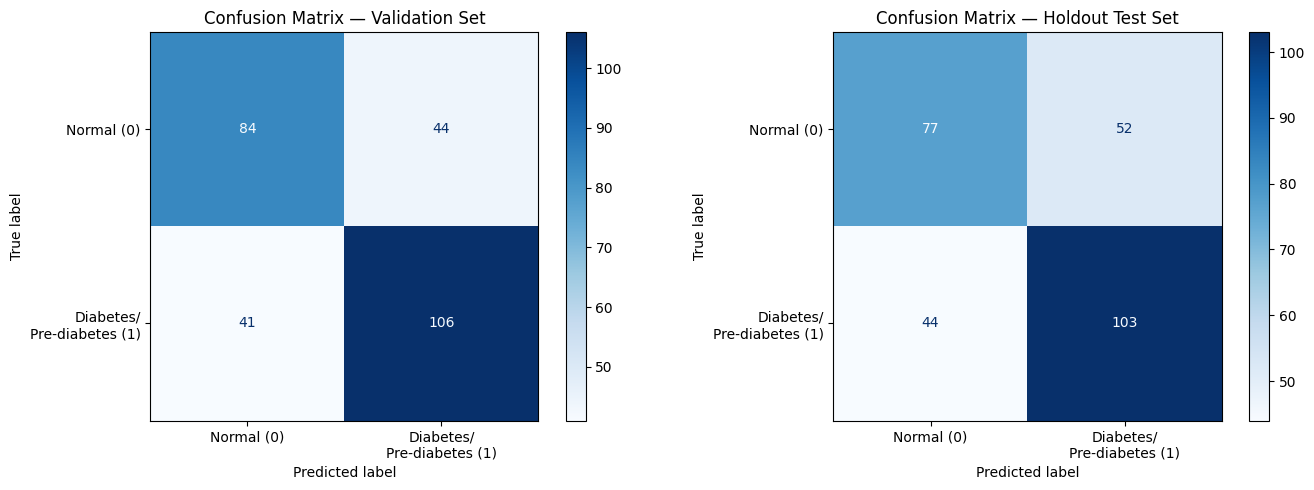

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_labels = ['Normal (0)', 'Diabetes/\nPre-diabetes (1)']

for ax, y_true, y_pred, title in [
    (axes[0], y_val, y_val_pred, 'Validation Set'),
    (axes[1], y_test, y_test_pred, 'Holdout Test Set')
]:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'Confusion Matrix — {title}')

plt.tight_layout()
plt.show()

### 5.3 Feature Importance

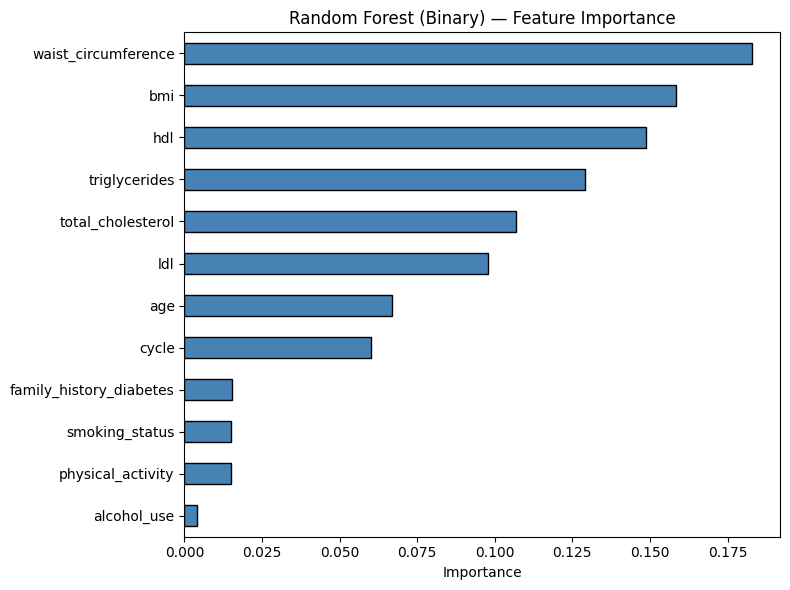

In [15]:
importances = best_model.named_steps['rf'].feature_importances_
feature_names = X_train.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Importance')
ax.set_title('Random Forest (Binary) — Feature Importance')
plt.tight_layout()
plt.show()